In [112]:
!pip install numpy pandas scipy scikit-learn tensorflow matplotlib

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from google.colab import files

In [114]:
WINDOW_SIZE = 128

CLASS_FILES = {
    "circle": "Circle.csv",
    "left_right": "Left-right.csv",
    "rest": "Rest.csv",
    "up_down": "Up-down.csv"
}

In [115]:
import os

for label, fname in CLASS_FILES.items():
    print(label, "->", fname, "exists:", os.path.exists(fname))

circle -> Circle.csv exists: True
left_right -> Left-right.csv exists: True
rest -> Rest.csv exists: True
up_down -> Up-down.csv exists: True


In [116]:
def load_windows_from_csv(filepath, window_size=128):
    import pandas as pd
    import numpy as np

    df = pd.read_csv(filepath)

    if len(df.columns) == 1:
        col = df.columns[0]
        df = df[col].str.split(',', expand=True)
        df.columns = ['aX','aY','aZ','gX','gY','gZ']

    df = df.apply(pd.to_numeric, errors='coerce')

    df = df.dropna().reset_index(drop=True)

    values = df.values.astype(np.float32)

    num_windows = len(values) // window_size
    values = values[:num_windows * window_size]

    windows = values.reshape(num_windows, window_size, 6)

    return windows

In [117]:
all_data = {}

for label, filepath in CLASS_FILES.items():
    windows = load_windows_from_csv(filepath, WINDOW_SIZE)
    all_data[label] = windows
    print(label, windows.shape)

circle (40, 128, 6)
left_right (38, 128, 6)
rest (40, 128, 6)
up_down (40, 128, 6)


In [121]:
from scipy.signal import welch
import numpy as np

def extract_features_from_window(window, fs=100):
    features = []

    for axis in range(window.shape[1]):
        signal = window[:, axis]

        mean_val = np.mean(signal)
        std_val = np.std(signal)
        rms_val = np.sqrt(np.mean(signal ** 2))
        min_val = np.min(signal)
        max_val = np.max(signal)

        freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), 64))
        dominant_freq = freqs[np.argmax(psd)]
        peak_psd = np.max(psd)

        features.extend([
            mean_val,
            std_val,
            rms_val,
            min_val,
            max_val,
            dominant_freq,
            peak_psd
        ])

    return np.array(features, dtype=np.float32)

In [122]:
X = []
y = []

label_to_index = {label: idx for idx, label in enumerate(CLASS_FILES.keys())}
index_to_label = {idx: label for label, idx in label_to_index.items()}

for label, windows in all_data.items():
    for window in windows:
        feats = extract_features_from_window(window, fs=100)
        X.append(feats)
        y.append(label_to_index[label])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature dimension:", X.shape[1])
print("Labels:", label_to_index)

X shape: (158, 42)
y shape: (158,)
Feature dimension: 42
Labels: {'circle': 0, 'left_right': 1, 'rest': 2, 'up_down': 3}


In [124]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (94, 42) (94,)
Val: (32, 42) (32,)
Test: (32, 42) (32,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)

Scaled train shape: (94, 42)


In [ ]:
import tensorflow as tf

num_classes = len(CLASS_FILES)
input_dim = X_train_scaled.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,964 (19.39 KB)

 Trainable params: 4,964 (19.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=8,
    verbose=1
)

Epoch 1/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2599 - loss: 1.4348 - val_accuracy: 0.8125 - val_loss: 0.8285
Epoch 2/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7783 - loss: 0.9870 - val_accuracy: 1.0000 - val_loss: 0.5097
Epoch 3/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9554 - loss: 0.5160 - val_accuracy: 1.0000 - val_loss: 0.3496
Epoch 4/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9965 - loss: 0.3109 - val_accuracy: 1.0000 - val_loss: 0.2356
Epoch 5/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.2414 - val_accuracy: 1.0000 - val_loss: 0.1459
Epoch 6/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.1532 - val_accuracy: 1.0000 - val_loss: 0.0904
Epoch 7/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0892 - val_accuracy: 1.0000 - val_loss: 0.0592
Epoch 8/60
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0586 - val_accuracy: 1.0000 - val_los

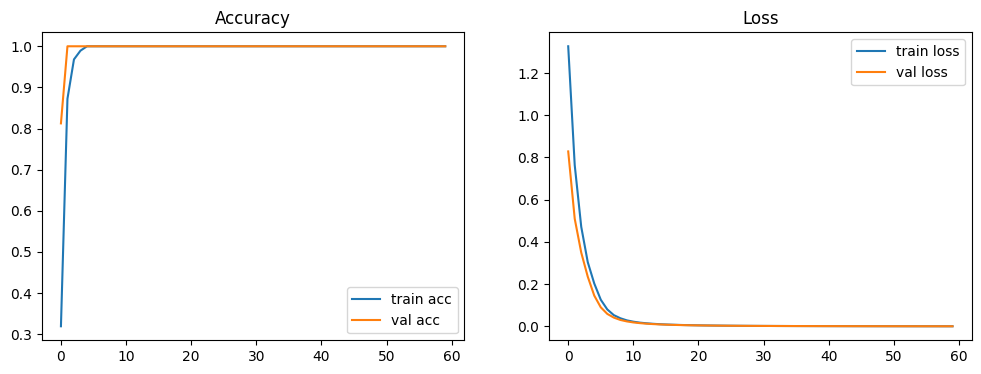

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()

plt.savefig("training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test Accuracy:", test_acc)

Test Accuracy: 1.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
              precision    recall  f1-score   support

      circle       1.00      1.00      1.00         8
  left_right       1.00      1.00      1.00         8
        rest       1.00      1.00      1.00         8
     up_down       1.00      1.00      1.00         8

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32

              precision    recall  f1-score   support

      circle       1.00      1.00      1.00         8
  left_right       1.00      1.00      1.00         8
        rest       1.00      1.00      1.00         8
     up_down       1.00      1.00      1.00         8

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



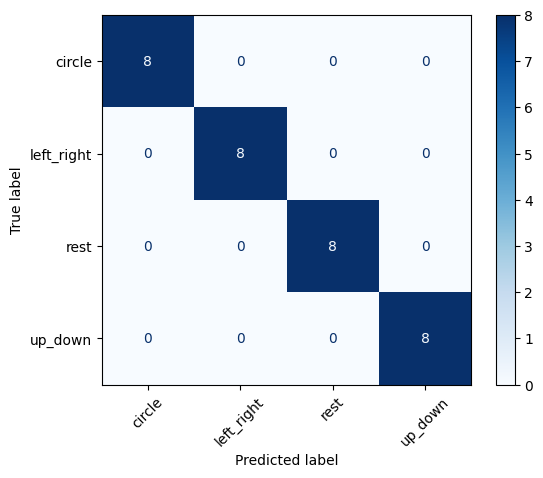

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=list(CLASS_FILES.keys())))
report = classification_report(y_test, y_pred, target_names=list(CLASS_FILES.keys()))
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(CLASS_FILES.keys()))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("gesture_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved gesture_model.tflite")

Saved artifact at '/tmp/tmp0e3wfaqf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139655126487632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655126494928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655126495504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655283481616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655283486224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139655283489296: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved gesture_model.tflite


In [ ]:
!xxd -i gesture_model.tflite > model.h

In [ ]:
np.set_printoptions(suppress=True)

print("SCALER_MEAN = {")
print(", ".join(map(str, scaler.mean_.tolist())))
print("}")

print("\nSCALER_SCALE = {")
print(", ".join(map(str, scaler.scale_.tolist())))
print("}")

SCALER_MEAN = {
0.2035248240361862, 0.13101443281258515, 0.4087896834504097, -0.005871117590589726, 0.41774933049554364, 3.6735372340425534, 0.004543569979306723, -0.4051204133850641, 0.11144093590778635, 0.43320846450118783, -0.6653338321187394, -0.1487712557774354, 3.956117021276596, 0.0027530031441219374, -0.3219971065496174, 0.07795864561612302, 0.5537368378582153, -0.4897278831043142, -0.12387541412039006, 9.80718085106383, 0.002278706793509008, -0.20037304768536954, 14.229078778561126, 14.569910565589337, -38.078793056467745, 33.49206632882991, 7.446808510638298, 36.656519621214336, 0.9792104692376674, 11.607819968715628, 11.952036879164107, -24.2277090549469, 28.448225378990173, 3.939494680851064, 144.59467503333346, -0.5070402856044313, 25.529095964862947, 25.874784125926645, -43.98491775101804, 52.89605111581214, 2.210771276595745, 251.98656402873073
}

SCALER_SCALE = {
0.42973531052785063, 0.13566931691171785, 0.3075007828925677, 0.5188522885003986, 0.42332605202498247, 4.068

In [ ]:
with open("scaler_values.txt", "w") as f:
    f.write("SCALER_MEAN = {\n")
    f.write(", ".join(map(str, scaler.mean_.tolist())))
    f.write("\n}\n\n")
    f.write("SCALER_SCALE = {\n")
    f.write(", ".join(map(str, scaler.scale_.tolist())))
    f.write("\n}\n")

In [ ]:
from google.colab import files

files.download("classification_report.txt")
files.download("confusion_matrix.png")
files.download("training_curves.png")
files.download("gesture_model.tflite")
files.download("model.h")
files.download("scaler_values.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>